In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import gymnasium as gym
import matplotlib.pyplot as plt

import random
from collections import deque

import copy

import numpy as np

env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=16, render_mode = "rgb_array")

#Variables
gamma = 0.99
alpha = 0.2
epsilon = 1.0
epsilonmin = 0.0
epsilondecay = 0.99999


In [30]:
def x(raw_grid):
  
    ret = torch.zeros((1, 16, 4, 4), dtype=torch.float32)
    for i in range(4):
        for j in range(4):
            if raw_grid[i][j] != 0:
                val = int(raw_grid[i][j]) 
                
                ret[0, val - 1, i, j] = 1.0
    return ret

In [31]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=128, kernel_size=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=2), 
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )
        
    def forward(self, x):
        x = self.convs(x)
        return self.fc(x)

In [32]:
class Replay:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, n):
        ret = random.sample(self.buffer, n)
        return ret
    def size(self):
        return len(self.buffer)

class DQN:
    def __init__(self):
        self.policy = Net()
        self.target = Net()
        self.target.load_state_dict(self.policy.state_dict())
        self.target.eval()
        self.optimizer = optim.Adam(self.policy.parameters(), lr=alpha)
        self.criteria = nn.MSELoss()
        self.replay = Replay(capacity=10000)
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilonmin = epsilonmin
        self.epsilondecay = epsilondecay
        self.samplesize = 1000
        self.account = [0, 0, 0, 0]
    def decay(self):
        self.epsilon *= self.epsilondecay
        self.epsilon = max(self.epsilon, self.epsilonmin)
    def A(self, state):
        if random.random() < self.epsilon:
            return random.randrange(4)
        else:
            q = self.policy(state)
            self.account[torch.argmax(q).item()] += 1
            return torch.argmax(q).item()
    def propogate(self):
        if self.replay.size() < self.samplesize:
            return None
        replay = self.replay.sample(self.samplesize)
        states, actions, rewards, next_states, dones = zip(*replay)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        states = torch.stack(states).squeeze(1)
        next_states = torch.stack(next_states).squeeze(1)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)
        q = self.policy(states).squeeze(1).gather(1, actions)
        #print(q)
        with torch.no_grad():
            mq = self.target(next_states).max(1)[0].unsqueeze(1)
            q_ = rewards + (self.gamma*mq*(1-dones)) 
        loss = self.criteria(q, q_)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()   
        return loss

In [33]:
def render_board(env):

    frame = env.render()

    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis('off')  
    plt.show()

In [34]:
def plot_results(scores, losses, window=50):
    def get_moving_average(data, w):
        return [sum(data[max(0, i-w+1):i+1]) / len(data[max(0, i-w+1):i+1]) for i in range(len(data))]
    scores_ma = get_moving_average(scores, window)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(scores, alpha=0.3, color='blue', label='Raw Score') 
    ax1.plot(scores_ma, color='darkblue', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax1.set_title("Total Score per Episode")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Score")
    ax1.legend()
    ax2.plot(losses, color='orange', alpha=0.3, label='Raw Loss')
    ax2.set_title("Average Loss per Episode")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Loss")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

10
200
903.2
0.9873999898860718
----
218
20
508
1101.2
0.974227791457223
----
384
30
492
1049.6
0.9610006449375953
----
588
40
688
1282.8
0.9462009833705525
----
822
50
564
1016.8
0.9334663682329558
----
1043
60
488
1125.2
0.9202219245399927
----
1258
70
280
1059.2
0.9071200416510868
----
1522
80
176
1204.4
0.8937755825930518
----
1767
90
608
1241.6
0.8798968099960297
----
2027
100
616
1216.4
0.866684111313908
----
2266
110
588
1346.0
0.8524925593015343
----
2546
120
324
958.8
0.8415407318967772
----
2760
130
352
1248.0
0.828564212737939
----
3029
140
288
1024.4
0.8177316878859443
----
3220
150
204
1128.8
0.8061454630942276
----
3435
160
468
978.0
0.7956537756620925
----
3642
170
256
1075.2
0.7846784896603548
----
3875
180
508
1086.8
0.7732280257145046
----
4187
190
160
788.4
0.7639970539130924
----
4423
200
428
1066.4
0.7529462620952763
----
4699


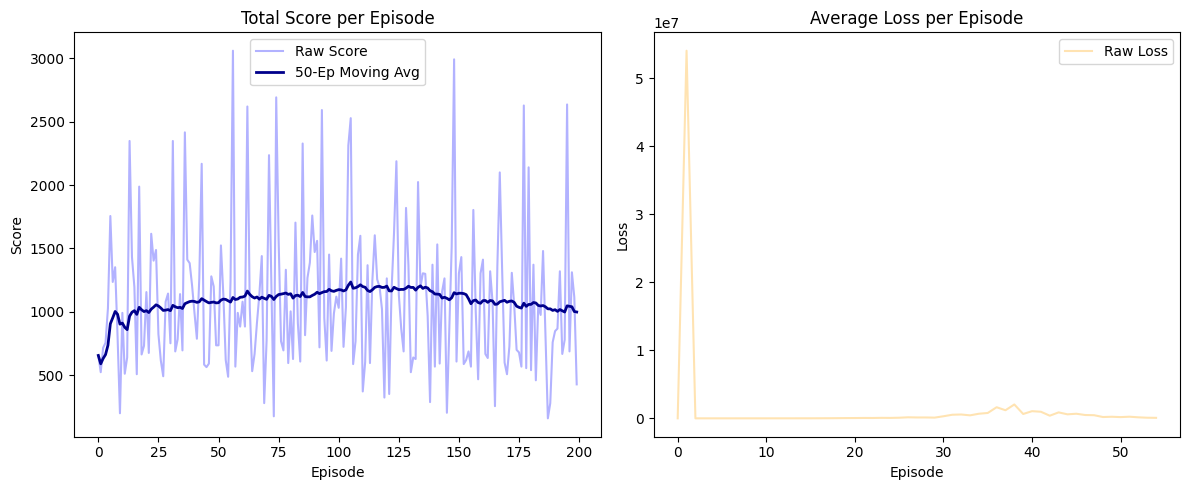

210
596
1064.4
0.7425229583039927
----
4951
220
220
1181.2
0.7315705900197952
----
5214
230
540
1164.0
0.7203978574766
----
5510
240
500
1069.2
0.7099067091737444
----
5800
250
708
1520.8
0.6965109193959946
----
6234
260
604
1087.6
0.6859970960620934
----
6551
270
584
1102.0
0.6751759442605232
----
6928
280
652
1434.4
0.6628861282818133
----
7338
290
592
1257.6
0.65117155580244
----
7814
300
320
1039.6
0.6413421295764964
----
8184
310
684
1121.6
0.6310675930131993
----
8560
320
528
1394.0
0.619648812415563
----
8996
330
376
959.2
0.6109546997848113
----
9305
340
580
1406.8
0.5991025092023113
----
9823
350
644
1078.4
0.5897523120776262
----
10209
360
524
1450.8
0.5786295967107042
----
10700
370
324
808.4
0.5708305900277967
----
11060
380
420
908.4
0.5624444657592464
----
11490
390
564
936.0
0.5538879029428478
----
11915
400
548
1256.8
0.5434905017157549
----
12509


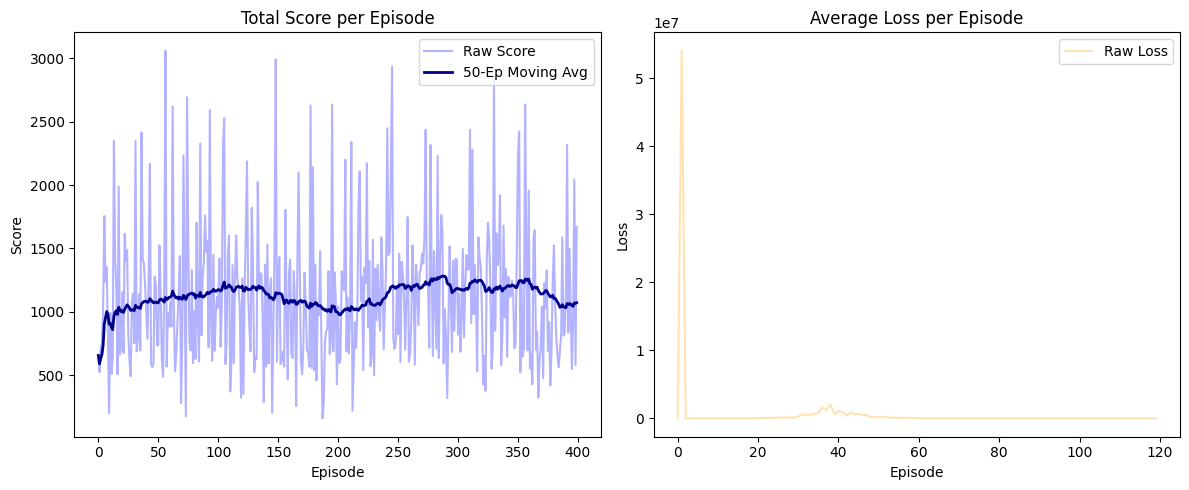

410
412
1217.2
0.5333309420609791
----
13085
420
448
970.0
0.525028243067444
----
13541
430
256
1360.8
0.5150489586643826
----
14107
440
436
979.2
0.5071373550269171
----
14545
450
672
1120.8
0.4981303523657414
----
15112
460
672
1212.8
0.4888138294494617
----
15706
470
712
1257.2
0.4794509540159723
----
16324
480
456
1166.8
0.47048849643210056
----
16974
490
656
1254.8
0.4617674528316324
----
17549
500
560
972.4
0.4534256569479571
----
18250
[10813, 6343, 379, 6864]


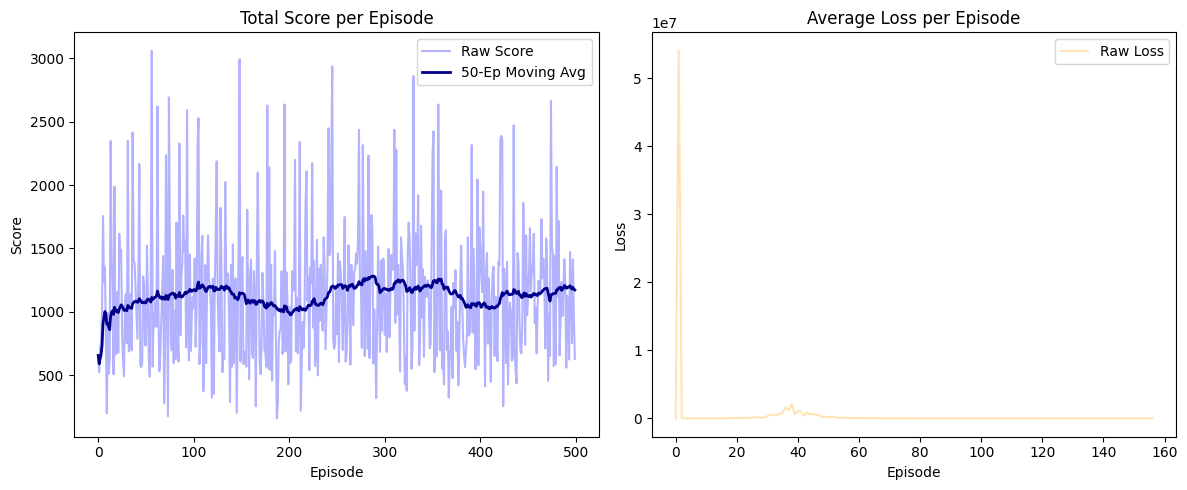

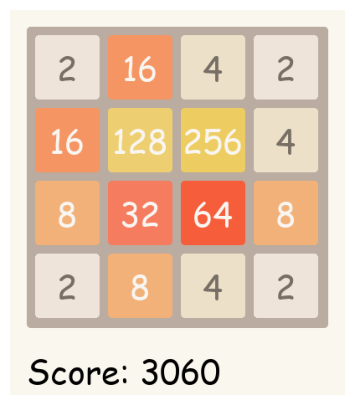

In [35]:
losses = []
scores = []
episodes = 500
freq = 500
c = 0
maxscore = 0
maxenv = None
rcount = 0

rmap = [[ 10.0,  8.0,  7.0,  6.5],
        [  4.0,  5.0,  5.5,  6.0],
        [  3.5,  3.0,  2.5,  2.0],
        [ -1.0,  0.0,  1.0,  1.5]]

agent = DQN()
minscore = 1000000
totalscore = 0
for episode in range(episodes):
    _, fate = env.reset()
    done = False
    s = 0
    ls = 0
    t = 0
    prev = 0
    while not done:
        grid = fate['board']
        inp = x(grid)
        a = agent.A(inp)
        next_state, reward, done, _, next_fate  = env.step(a)
        s+=reward
        reward = 0
        b = next_fate['board']
        for i in range(0,4):
            for j in range(0, 4):
                reward += rmap[i][j]*b[i][j]
        if np.array_equal(fate['board'], next_fate['board']):
            reward = -5
            rcount += 1
        agent.replay.push(x(fate['board']), a, reward - prev, x(next_fate['board']), done)
        fate = next_fate
        c += 1
        if(c%freq == 0):
            l = agent.propogate()
            if l is not None:
                ls += l
                t += 1
            agent.target.load_state_dict(agent.policy.state_dict())
        agent.decay()
        prev = reward
        
    if(s > maxscore):
        maxenv = copy.deepcopy(env)
        maxscore = s
    scores.append(s)
    totalscore += s
    minscore = min(s, minscore)
    if(t>0):
        losses.append((ls/t).item())
    if((episode+1)%10 == 0):
        print(episode + 1)
        print(minscore)
        print(totalscore/10)
        print(agent.epsilon)
        print('----')
        print(rcount)
        minscore = 1000000
        totalscore = 0
    if((episode+1)%200 == 0):
        plot_results(scores, losses)
print(agent.account)
plot_results(scores, losses)
render_board(maxenv)
    